In [5]:
import numpy as np
import astropy.units as u
import glob
import os

import colorsys
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmcrameri.cm as cmc
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

In [ ]:
# Info to get search results
SOURCE = "2022_CHIME_B2111+46"
OBS_NIGHT = "20220826T064420Z"
RESULTS_DIR = f"/scratch/abernier/pulsar_data/search_results/{SOURCE}/{OBS_NIGHT}"
SETTINGS = "timeavg391_nfiles65_start160_RFI1.7mean1.3std"
PARAM = "search_downsamp_factor"  # Specify which parameter was varied in the search results to plot
PARAM_LABEL = "Downsampling Factor"  # Label for the x-axis corresponding to the varied parameter (e.g., 'Downsampling Factor', 'DM [pc/cm^3]')
PARAM_DIR = f"{RESULTS_DIR}/{SETTINGS}/{PARAM}/"
BURST_LIMS = [1.10, 1.15]
if BURST_LIMS == [0]:
    BURST_LIMS = None  # interpret burst_lims of 0 as no limits (i.e. use full time range for plots)

# Search result files
METADATA_FILES = sorted(glob.glob(os.path.join(PARAM_DIR, f"{PARAM}*_metadata.npz")), key=len)
TIMINGS_FILES = sorted(glob.glob(os.path.join(PARAM_DIR, f"{PARAM}*_timings.npz")), key=len)
DATA_FILES = sorted(glob.glob(os.path.join(PARAM_DIR, f"{PARAM}*_arrays.npz")), key=len)
NFILES = len(DATA_FILES)  # number of files to plot
DATA_FILES_UNIQUE = True   # determines if masked+normalized stokes data is the same for all values of the varied params or not
                           # True if data is unique, false if data changes with each run of param

# Save directory for figures
SOURCE_AND_NIGHT = f"{RESULTS_DIR.split('/')[-2]}/{RESULTS_DIR.split('/')[-1]}"
SAVE_FIG_DIR = f'/scratch/abernier/rm-search-Bernier-2025/figures/{SOURCE_AND_NIGHT}/{SETTINGS}/{PARAM}/'
os.makedirs(os.path.dirname(SAVE_FIG_DIR), exist_ok=True)

In [7]:
# Open Results
# ------------------------------------------------------------------------------
param_list = []
data = {}
metadata = {}
timings = {}

for data_file, metadata_file, timings_file in zip(DATA_FILES, METADATA_FILES, TIMINGS_FILES):
    # Get parameter value from filename
    filename = os.path.basename(data_file)  # format: param_name{param_value}_arrays.npz
    param_value = float(filename.split("_")[-2]) 
    param_list.append(param_value)

    # Load data
    with np.load(data_file, allow_pickle=True) as df:
        data_dict = {k: df[k] for k in df.files}
        data[param_value] = data_dict

    # Load metadata
    with np.load(metadata_file, allow_pickle=True) as mf:
        metadata[param_value] = mf['metadata'][0]

    # Load timings
    with np.load(timings_file, allow_pickle=True) as tf:
        timings[param_value] = tf['timings'][0]

param_list = sorted(param_list)

In [8]:
# Get true RMs (using 1st file)
# ------------------------------------------------------------------------------
rm_true = list(metadata[param_list[0]]['true_rms_rad_m2'].value)  # true RM of real data
if metadata[param_list[0]]['sim_flag']:
    sim_rm = metadata[param_list[0]]['sim_params']["rm"]  # true RM of injected bursts
    rm_true.append(sim_rm.value)
rm_true = np.array(rm_true)  # for now: assume shape is (1,)
rm_true = rm_true[0]

In [11]:
# ==========================================================================
# Phi distributions
# ------------------------------------------------------------------------------

In [9]:
# --- Compute relevant arrays ---
peak_snr_phi_dist = []
peak_snr_phi_dist_folded = []

# Go through params
for i, p in enumerate(param_list):
    # Data for this parameter value
    fdf = data[p]['FDF_arr']  # shape (Ntimes, Nphi)
    phi_arr = data[p]['phi_array']  # shape (Nphi,)
    time_arr = data[p]['time_slice_arr']  # shape (Ntimes,)
    phi_mask = np.abs(phi_arr) > 10 # exclude phi values between -10 and 10

    # -- Average FDF bw limits and get its S/N --
    # Get indices for burst limits
    inds = [
        np.argmin(np.abs(time_arr - BURST_LIMS[0])),
        np.argmin(np.abs(time_arr - BURST_LIMS[1]))
    ]
    data[p]['time_edges'] = (time_arr[inds[0]], time_arr[inds[1]])  # actual time limits used

    # Average fdf over time range
    fdf_phi_dist = abs(np.nanmean(fdf[inds[0]:inds[1]], axis=0))  # shape (Nphi,)
    fdf_phi_dist[~phi_mask] = np.nan
    data[p]['fdf_phi_dist'] = fdf_phi_dist  # add to data dict

    # Compute S/N for this slice (function of phi)
    slice_median = np.nanmedian(fdf_phi_dist, axis=0, keepdims=True)
    slice_sigma = np.nanstd(fdf_phi_dist, axis=0, keepdims=True)
    snr_phi_dist = np.divide(  # to avoid /0
        fdf_phi_dist - slice_median,
        slice_sigma,
        out=np.zeros_like(fdf_phi_dist),
        where=(slice_sigma != 0) & ~np.isnan(fdf_phi_dist)
    )  # shape (Nphi,)
    data[p]['snr_phi_dist'] = snr_phi_dist

    # Get max snr in phi dist.
    max_snr = np.nanmax(snr_phi_dist)
    peak_snr_phi_dist.append(max_snr)

    # -- Fold the FDF slice --
    phi_zero_ind = np.argmin(np.abs(phi_arr))  # index closests to phi=0 in phi_arr
    # Positive phi side (includes phi=0)
    phi_arr_folded = phi_arr[phi_zero_ind:]
    pos_phi_fdf = fdf_phi_dist[..., phi_zero_ind:]
    # Negative phi side reflected onto positive axis
    neg_phi_fdf = np.concatenate(
        [
            np.zeros(fdf_phi_dist.shape[:-1] + (1,)),  # shape (..., 1) of zeros for phi=0 bin
            np.flip(fdf_phi_dist[..., :phi_zero_ind], axis=-1)  # flip along phi axis (last axis)
        ],
        axis=-1  # concatenate along phi axis
    )
    # Folded FDF
    fdf_phi_dist_folded = (pos_phi_fdf + neg_phi_fdf)
    
    # Add to data dict
    data[p]['phi_arr_folded'] = phi_arr_folded
    data[p]['fdf_phi_dist_folded'] = fdf_phi_dist_folded
    data[p]['pos_fdf_phi_dist_folded'] = pos_phi_fdf
    data[p]['neg_fdf_phi_dist_folded'] = neg_phi_fdf

    # -- Compute S/N of folded FDF ---
    slice_median_folded = np.nanmedian(fdf_phi_dist_folded, axis=0, keepdims=True)
    slice_sigma_folded = np.nanstd(fdf_phi_dist_folded, axis=0, keepdims=True)
    snr_phi_dist_folded = np.divide(  # fdf slice/median but =0 where median is 0 to avoid divide-by-zero errors
        fdf_phi_dist_folded - slice_median_folded,
        slice_sigma_folded,
        out=np.zeros_like(fdf_phi_dist_folded),
        where=(slice_sigma_folded != 0) & ~np.isnan(fdf_phi_dist_folded)
    )  # shape (Nphi,)
    data[p]['snr_phi_dist_folded'] = snr_phi_dist_folded

    # Get max snr in phi dist.
    max_snr_folded = np.nanmax(snr_phi_dist_folded)
    peak_snr_phi_dist_folded.append(max_snr_folded)

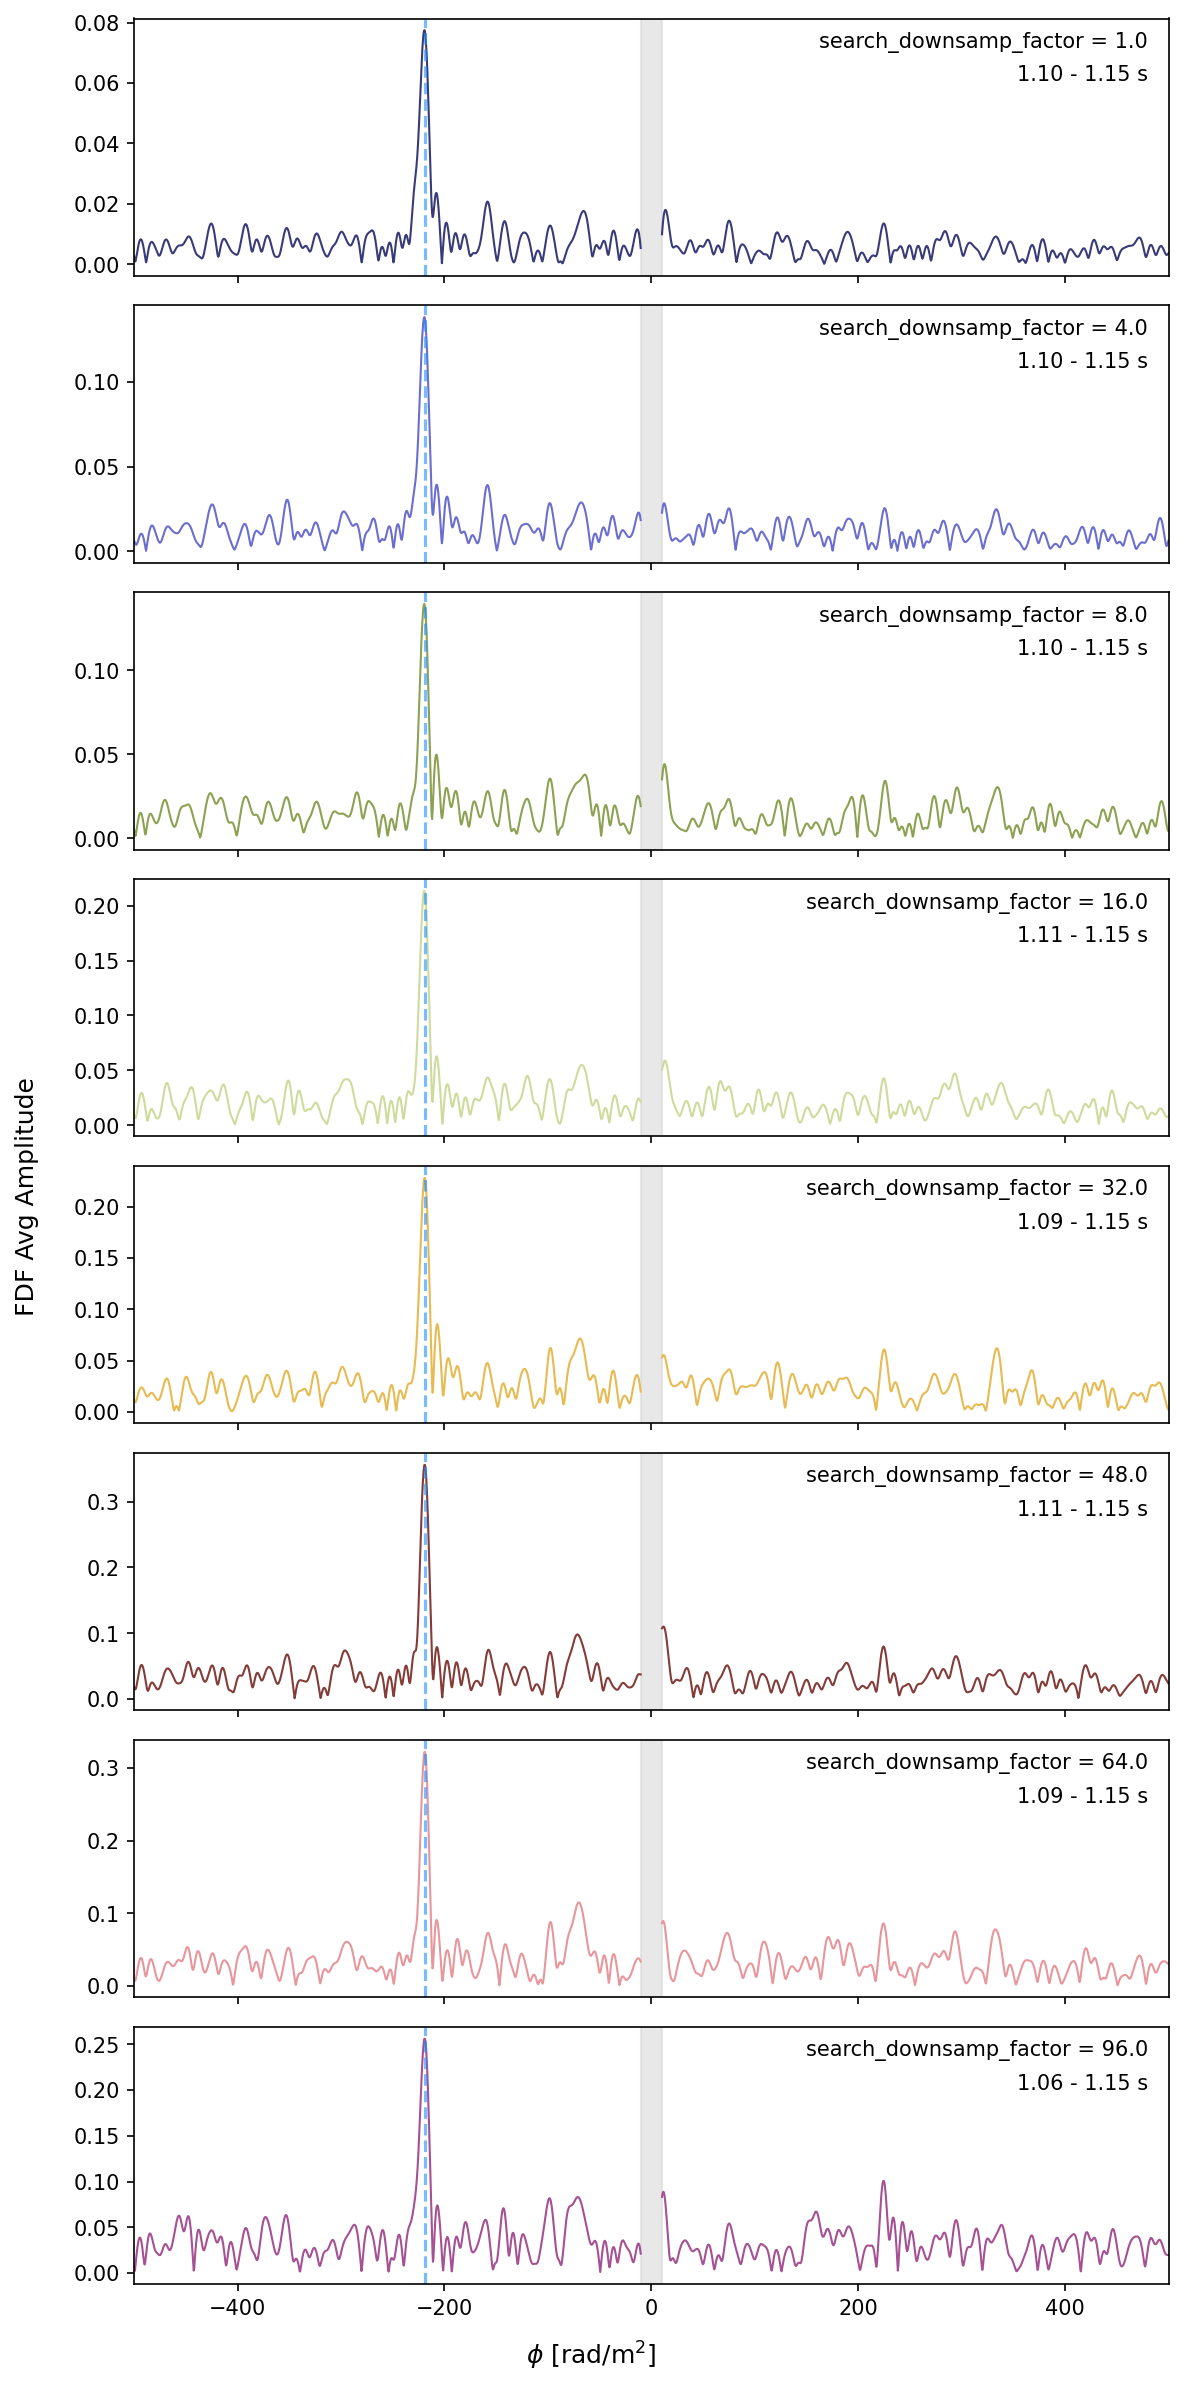

In [10]:
# --- Multi-panel plot: phi distribution amplitude around true time ---
# Setup figure
Nparams = len(param_list)
fig, axes = plt.subplots(
    Nparams, 1,
    figsize=(8, 2 * Nparams),
    dpi=150,
    sharex=True
)
if Nparams == 1:
    axes = [axes]
cmap = plt.colormaps["tab20b"]
colors = [cmap(i / Nparams) for i in range(Nparams)]

# go through all params
for i, p in enumerate(param_list):
    (tstart, tstop) = data[p]['time_edges']

    # plot phi distribution around burst for this parameter value
    axes[i].plot(data[p]['phi_array'], data[p]['fdf_phi_dist'], c=colors[i], lw=1, label=f"{tstart:.2f} - {tstop:.2f} s")
    axes[i].axvline(x=rm_true, label='True RM', c='dodgerblue', linestyle='--', alpha=0.6)
    axes[i].axvspan(-10, 10, alpha=0.5, color='lightgrey')

    # text
    axes[i].text(0.98, 0.95, f"{PARAM} = {p}", transform=axes[i].transAxes, ha='right', va='top')
    axes[i].text(0.98, 0.82, f"{tstart:.2f} - {tstop:.2f} s", transform=axes[i].transAxes, ha='right', va='top')


fig.supylabel("FDF Avg Amplitude")
fig.supxlabel(r'$\phi$ [rad/m$^2$]')
plt.xlim(-500,500)
plt.tight_layout()
plt.show()

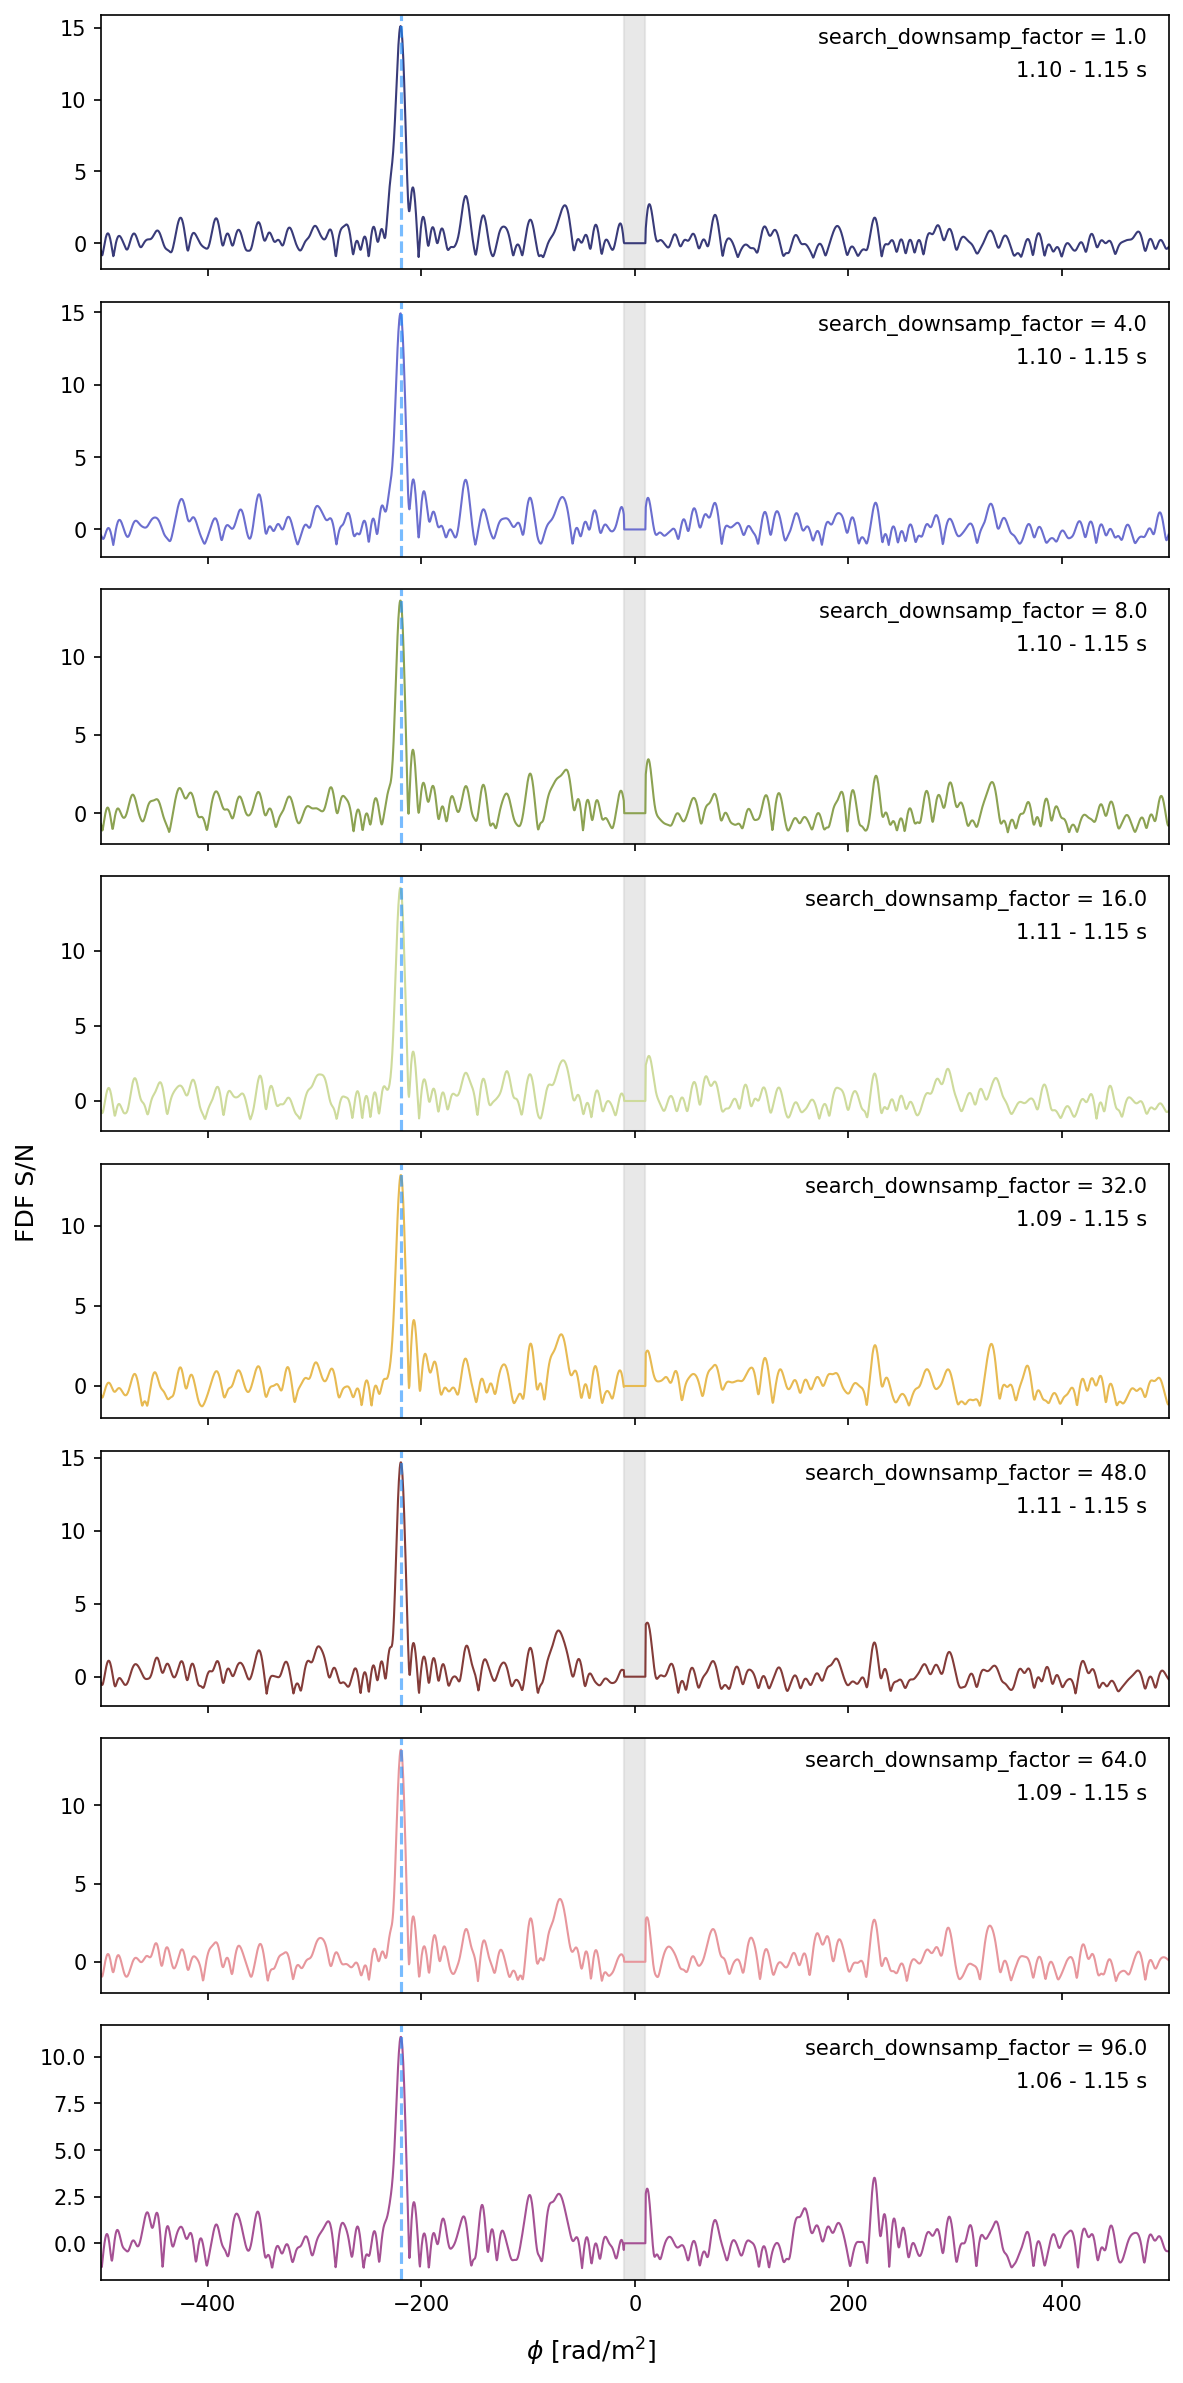

In [11]:
# --- Multi-panel plot: phi distribution S/N around true time ---
# Setup figure
Nparams = len(param_list)
fig, axes = plt.subplots(
    Nparams, 1,
    figsize=(8, 2 * Nparams),
    dpi=150,
    sharex=True
)
if Nparams == 1:
    axes = [axes]
cmap = plt.colormaps["tab20b"]
colors = [cmap(i / Nparams) for i in range(Nparams)]

# go through all params
for i, p in enumerate(param_list):
    (tstart, tstop) = data[p]['time_edges']

    # plot snr vs phi around burst for this parameter value
    axes[i].plot(data[p]['phi_array'], data[p]['snr_phi_dist'], c=colors[i], lw=1, label=f"{tstart:.2f} - {tstop:.2f} s")
    axes[i].axvline(x=rm_true, label='True RM', c='dodgerblue', linestyle='--', alpha=0.6)
    axes[i].axvspan(-10, 10, alpha=0.5, color='lightgrey')

    # text
    axes[i].text(0.98, 0.95, f"{PARAM} = {p}", transform=axes[i].transAxes, ha='right', va='top')
    axes[i].text(0.98, 0.82, f"{tstart:.2f} - {tstop:.2f} s", transform=axes[i].transAxes, ha='right', va='top')


fig.supylabel("FDF S/N")
fig.supxlabel(r'$\phi$ [rad/m$^2$]')
plt.xlim(-500,500)
plt.tight_layout()
plt.show()

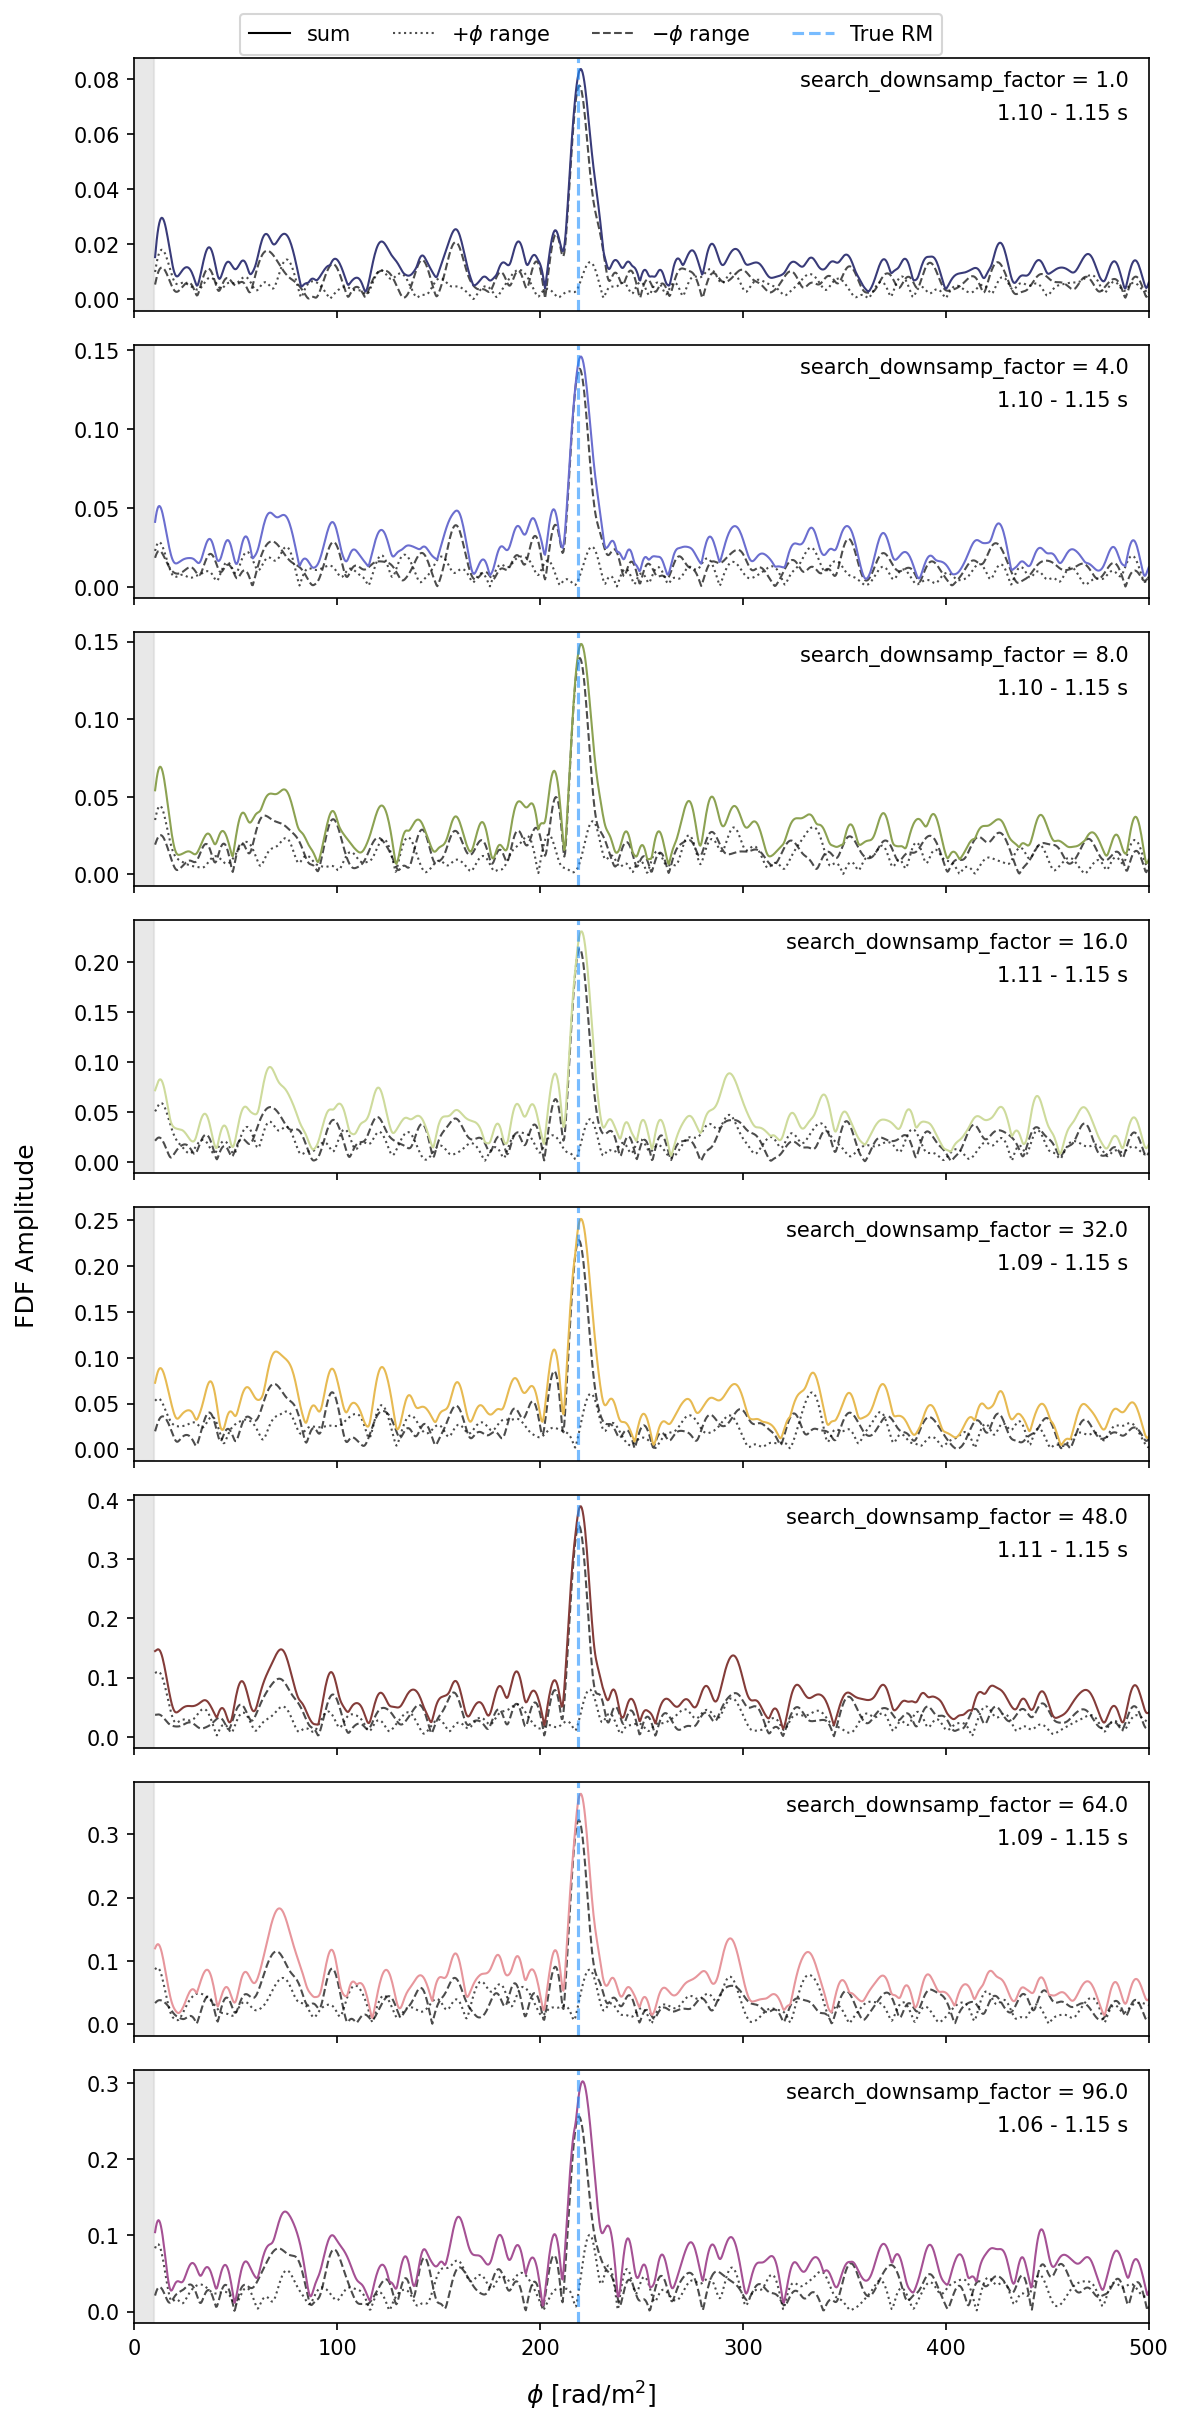

In [12]:
# --- Multi-panel plot: FOLDED phi distribution amplitude around true time ---
# Setup figure
Nparams = len(param_list)
fig, axes = plt.subplots(
    Nparams, 1,
    figsize=(8, 2 * Nparams),
    dpi=150,
    sharex=True
)
if Nparams == 1:
    axes = [axes]
cmap = plt.colormaps["tab20b"]
colors = [cmap(i / Nparams) for i in range(Nparams)]

# go through all params
for i, p in enumerate(param_list):
    (tstart, tstop) = data[p]['time_edges']
    folded_phi = data[p]['phi_arr_folded']

    # FDF lines
    pos_line, = axes[i].plot(folded_phi, data[p]['pos_fdf_phi_dist_folded'], 
                             lw=1, ls=":", c="k", alpha=0.7, label=f"$+\phi$ range")  # positive phi
    neg_line, = axes[i].plot(folded_phi, data[p]['neg_fdf_phi_dist_folded'], 
                             lw=1, ls="--", c="k", alpha=0.7, label=f"$-\phi$ range")  # negative phi
    axes[i].plot(folded_phi, data[p]['fdf_phi_dist_folded'], lw=1, c=colors[i])  # sum

    # other lines
    axes[i].axvline(x=abs(rm_true), label='True RM', c='dodgerblue', linestyle='--', alpha=0.6)
    axes[i].axvspan(0, 10, alpha=0.5, color='lightgrey')
    axes[i].text(0.98, 0.95, f"{PARAM} = {p}", transform=axes[i].transAxes, ha='right', va='top')
    axes[i].text(0.98, 0.82, f"{tstart:.2f} - {tstop:.2f} s", transform=axes[i].transAxes, ha='right', va='top')

# outside legend
combined_legend, = axes[0].plot([], [], color='k', lw=1, label="sum")
true_rm_line, = axes[0].plot([], [], c='dodgerblue', linestyle='--', alpha=0.6, label="True RM")
fig.legend(
    handles=[combined_legend, pos_line, neg_line, true_rm_line],
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.013)
)
fig.supylabel("FDF Amplitude")
fig.supxlabel(r'$\phi$ [rad/m$^2$]')
plt.xlim(0,500)
plt.tight_layout()
plt.show()

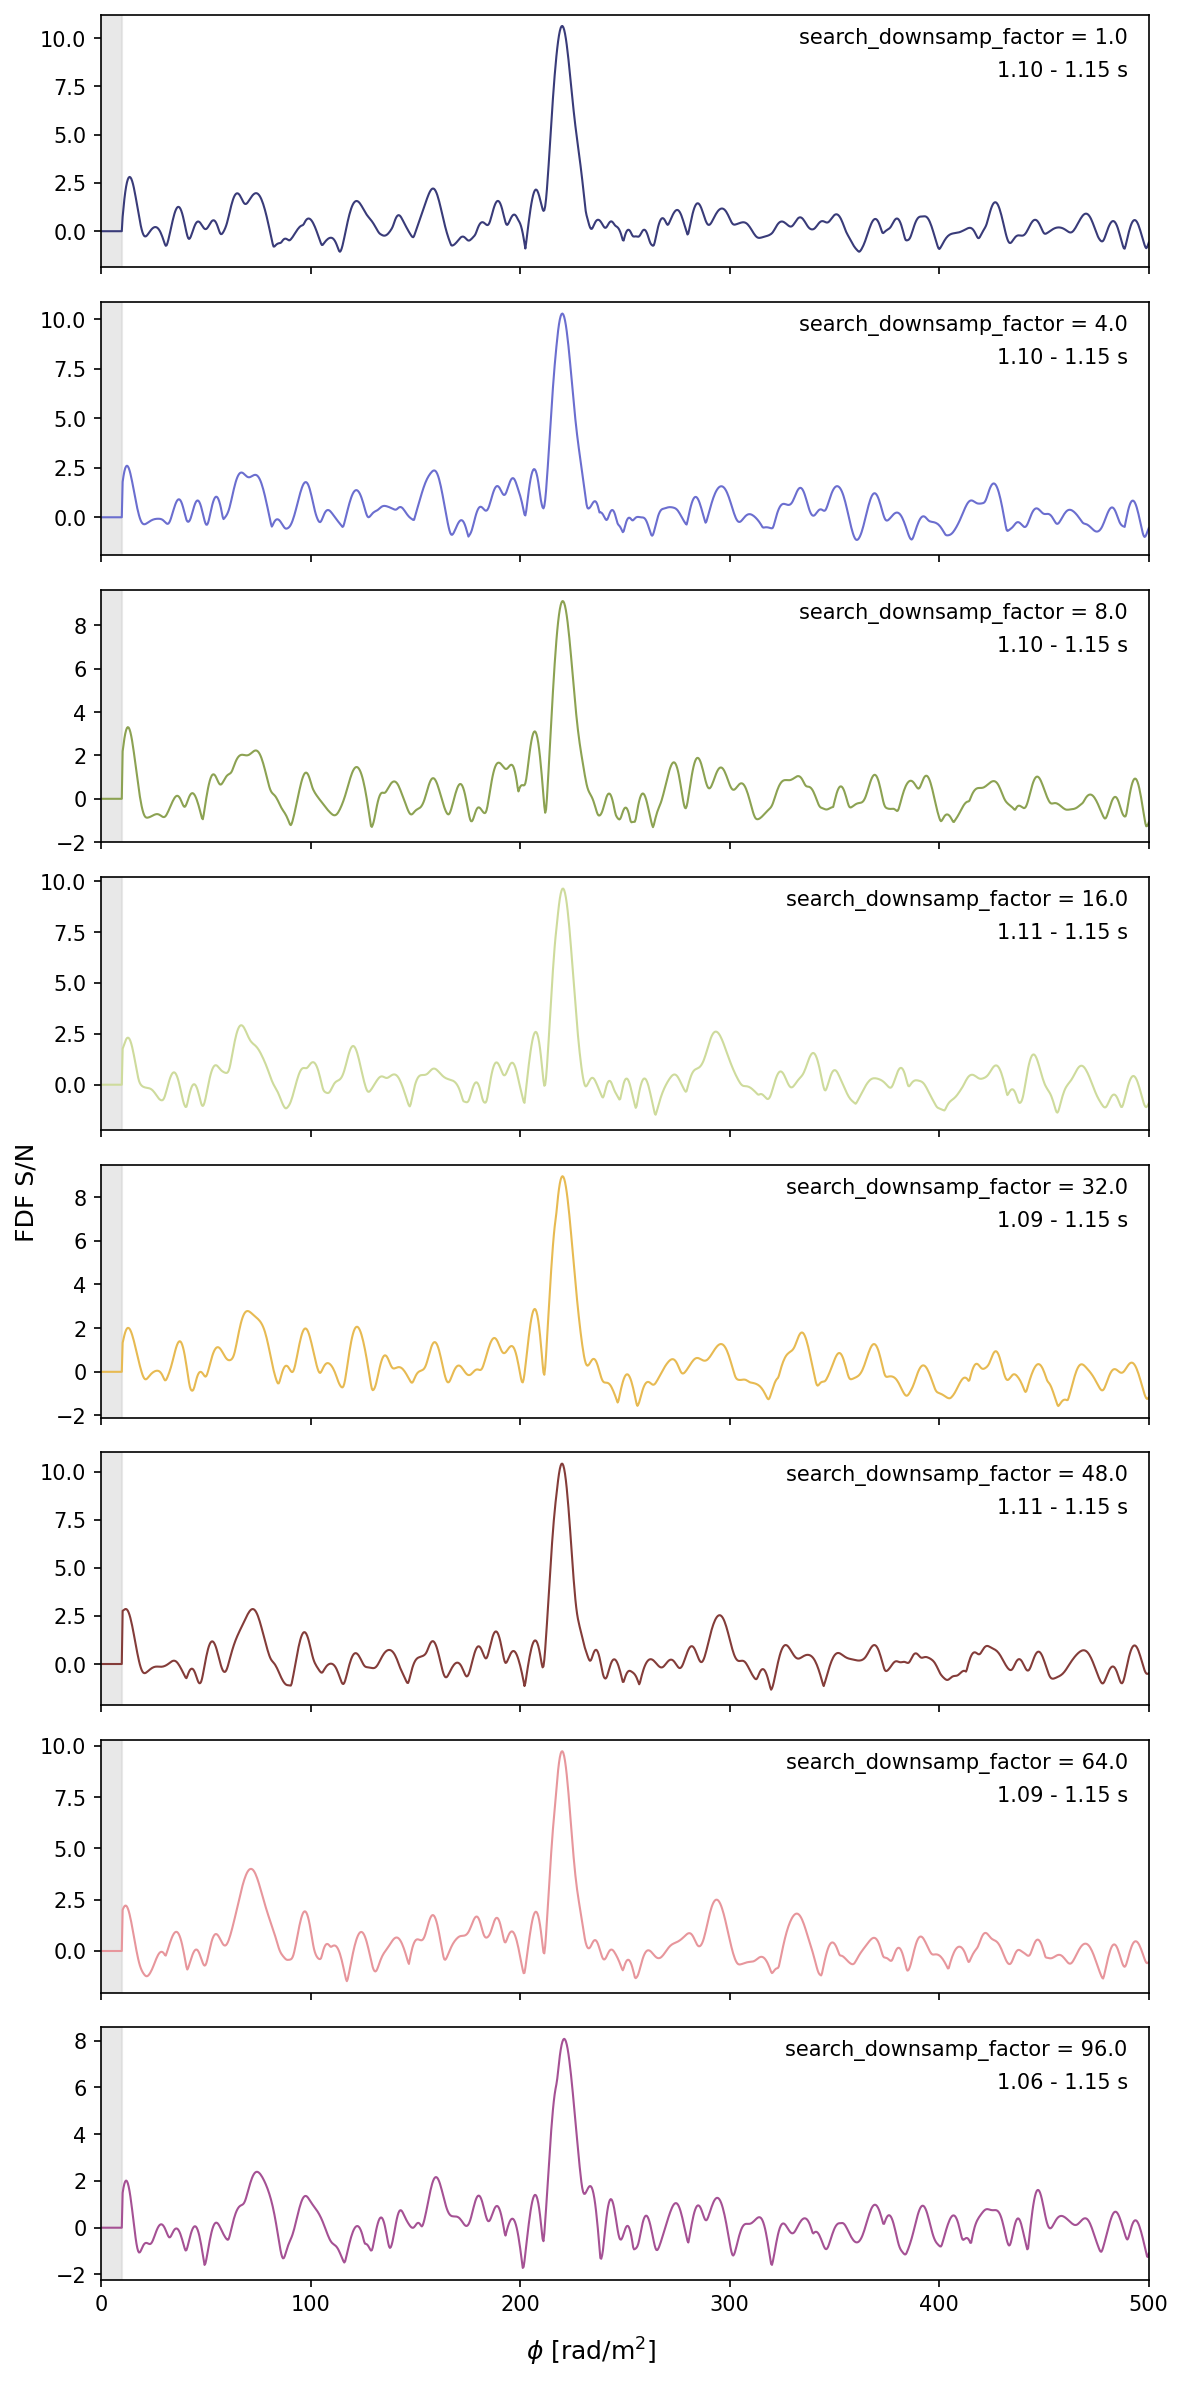

In [15]:
# --- Multi-panel plot: FOLDED phi distribution S/N around true time ---
# Setup figure
Nparams = len(param_list)
fig, axes = plt.subplots(
    Nparams, 1,
    figsize=(8, 2 * Nparams),
    dpi=150,
    sharex=True
)
if Nparams == 1:
    axes = [axes]
cmap = plt.colormaps["tab20b"]
colors = [cmap(i / Nparams) for i in range(Nparams)]

# go through all params
for i, p in enumerate(param_list):
    (tstart, tstop) = data[p]['time_edges']
    
    # plot snr vs phi around burst for this parameter value
    axes[i].plot(data[p]['phi_arr_folded'], data[p]['snr_phi_dist_folded'], c=colors[i], lw=1)
    axes[i].axvline(x=rm_true, label='True RM', c='dodgerblue', linestyle='--', alpha=0.6)
    axes[i].axvspan(0, 10, alpha=0.5, color='lightgrey')

    # text
    axes[i].text(0.98, 0.95, f"{PARAM} = {p}", transform=axes[i].transAxes, ha='right', va='top')
    axes[i].text(0.98, 0.82, f"{tstart:.2f} - {tstop:.2f} s", transform=axes[i].transAxes, ha='right', va='top')


fig.supylabel("FDF S/N")
fig.supxlabel(r'$\phi$ [rad/m$^2$]')
plt.xlim(0,500)
plt.tight_layout()
plt.show()

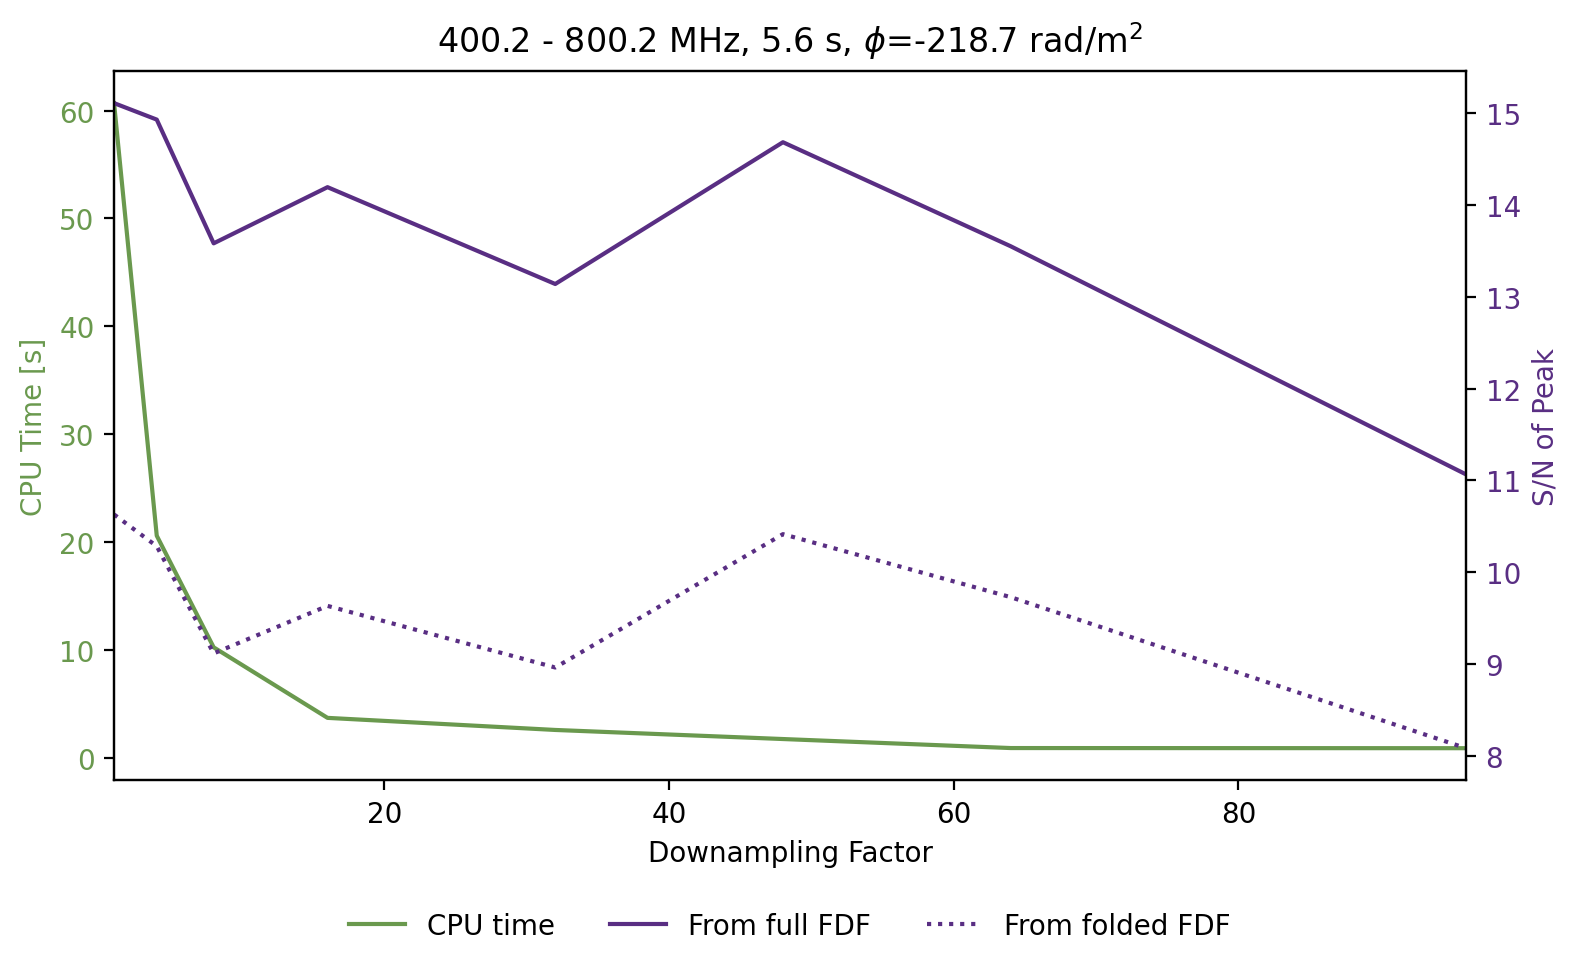

In [16]:
# --- Data info ---
fmin = metadata[param_list[0]]['fmin_MHz']
fmax = metadata[param_list[0]]['fmax_MHz']
delta_t_total_s = metadata[param_list[0]]['delta_t_total_s']

# --- Colors ---
rm_colors = ["#592e83", "#9984d4"]  # colors per burst
cpu_color = "#6a994e"

# --- Figure Setup ---
fig, ax1 = plt.subplots(figsize=(8,5), dpi=200)
fig.suptitle(rf"{fmin:.1f} - {fmax:.1f} MHz, {delta_t_total_s:.1f} s, $\phi$={rm_true} rad/m$^2$", y=0.95)

# --- Left Axis: CPU Time ---
cpu_data = [timings[p]['rm_search']['cpu_elapsed'] for p in param_list]
ax1.plot(param_list, cpu_data, color=cpu_color, label="CPU time")
ax1.set_xlabel(PARAM_LABEL)
ax1.set_ylabel("CPU Time [s]", color=cpu_color)
ax1.tick_params(axis='y', labelcolor=cpu_color)

# if plot_ylog:
# ax1.set_yscale("log")

# --- Right Axis: SNR ---
ax2 = ax1.twinx()
# for i in range(len(rm_true)):
i=0
ax2.plot(
    param_list,
    peak_snr_phi_dist,
    color=rm_colors[i],
    label=rf"From full FDF"
)
ax2.plot(
    param_list,
    peak_snr_phi_dist_folded,
    color=rm_colors[i],
    ls=":",
    label=rf"From folded FDF"
)
        
ax2.set_ylabel(r"S/N of Peak", color=rm_colors[0])
ax2.tick_params(axis='y', labelcolor=rm_colors[0])


# --- Legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False
)

plt.xlim(param_list[0], param_list[-1])
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()